# Inverse propensity weighting

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
#import shap
import statsmodels.api as sm

#from econml.dml import CausalForestDML # Causal forest with double machine learning
#from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier 

## Define mRS outcome target and cutoff for early treatment

In [2]:
MRS_TARGET = 2 # Model will set y as being less than or equal to this value

CUTOFF = 270

## Define adjustment fields

In [3]:
NON_CATEGORICAL_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'year',
    'onset_to_scan_time'
]

CATEGORICAL_FEATURES = [
    'stroke_team',
    'ethnicity',
    'treatment_group'
]

"""
X is the set of variables you want the treatment effect to depend on. # The causal forest builds 
trees that split on X, grouping patients so that the treatment effect is roughly constant within
a leaf.

W is the set of variables you want to control for. The causal forest will adjust for these 
variables, but will not split on them.

A feature belongs in X if you think the treatment effect may vary with it, and in W if it's a
confounder you need to adjust away. Many variables are both a confounder and an effect modifier, 
so they legitimately belong in both groups.
"""


X_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
]

W_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
    'stroke_team',
    'year',
    'onset_to_scan_time'
]

TREATMENTS = [
    'onset_to_thrombolysis_time',
    'onset_to_thrombectomy_time',
]

# Combine the X and W treatment features into a single list of features
cf_features = list(set(X_FEATURES + W_FEATURES + TREATMENTS))
descriptive_features = list(set(NON_CATEGORICAL_FEATURES + CATEGORICAL_FEATURES))

## Load and filter data

In [4]:
data = pd.read_csv("../../data/sam3/cleaned_data.csv", low_memory=False)

# Calculate onset_to_scan
data["onset_to_scan_time"] = data["onset_to_arrival_time"] - data["arrival_to_scan_time"]

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 360 mins
data = data[data["onset_to_arrival_time"] < 360]

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Limit to stroke severity  > 5 
data = data[((data["stroke_severity"] > 5) | data["lvo"] == 1)]

# Keep only teams with at least 10 onset_to_thrombectomy_time
team_counts = data.groupby("stroke_team")["onset_to_thrombectomy_time"].count()
valid_teams = team_counts[team_counts >= 10].index
data = data[data["stroke_team"].isin(valid_teams)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)
data["onset_to_thrombectomy_time"] = data["onset_to_thrombectomy_time"].fillna(99999)

# Remove rows where thrombolysis is after thrombectomy (if both are present)
both_treatments = (
    (data["onset_to_thrombolysis_time"] < 99999)
    & (data["onset_to_thrombectomy_time"] < 99999)
)
thrombolysis_after_thrombectomy = (
    data["onset_to_thrombolysis_time"] > data["onset_to_thrombectomy_time"]
)
data = data[~(both_treatments & thrombolysis_after_thrombectomy)]

# Exclude late thrombectomy (> 720) unless sentinel
data = data[
    (data["onset_to_thrombectomy_time"] < 720)
    | (data["onset_to_thrombectomy_time"] == 99999)
]

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] < 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

# Restrict data to cf_features, and keep only complete rows
data = data[cf_features + ["discharge_disability"]].dropna()

print(f"Final data shape: {data.shape}")

# Treatment counts
num_thrombectomy = (data["onset_to_thrombectomy_time"] != 99999).sum()
print(f"Number of patients with thrombectomy: {num_thrombectomy}")

num_both = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] != 99999)
).sum()
print(f"Number of patients with both thrombolysis and thrombectomy: {num_both}")

num_only_thrombectomy = (
    (data["onset_to_thrombectomy_time"] != 99999)
    & (data["onset_to_thrombolysis_time"] == 99999)
).sum()
print(f"Number of patients with only thrombectomy: {num_only_thrombectomy}")

num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")

num_only_thrombolysis = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] == 99999)
).sum()
print(f"Number of patients with only thrombolysis: {num_only_thrombolysis}")

Initial data shape: (452863, 71)
Final data shape: (59516, 15)
Number of patients with thrombectomy: 4608
Number of patients with both thrombolysis and thrombectomy: 2876
Number of patients with only thrombectomy: 1732
Number of patients with thrombolysis: 26907
Number of patients with only thrombolysis: 24031


Add treatment columns and patient ID

In [5]:
# Add treatment columns

TIME_THROMBOLYSIS = "onset_to_thrombolysis_time"
TIME_THROMBECTOMY = "onset_to_thrombectomy_time"

def add_treatment_columns(data):
    """
    Add treatment column based on use and time of thrombolysis only.
    Use CUTOFF to determine whether treatment is early or late.
    Sentinel value of 99999 means no treatment. 
    """

    data["treatment_group"] = "neither"
    # Early thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "early_thrombolysis_only"
    # Late thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) & (data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "late_thrombolysis_only"
    # Early thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] < CUTOFF), 
             "treatment_group"] = "early_thrombectomy_only"
    # Late thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] >= CUTOFF) &
             (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_thrombectomy_only"
    # Early thrombolysis and early thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] < CUTOFF),
             "treatment_group"] = "early_both"
    # Early thrombolysis and late thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] >= CUTOFF) & 
             (data[TIME_THROMBECTOMY] != 99999), 
             "treatment_group"] = "early_thrombolysis_late_thrombectomy"
    # Late both thrombolysis and thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) &(data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] > CUTOFF) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_both"

    return data

data = add_treatment_columns(data)

In [6]:
# Create treatment groups depending  on whether no treatment, thrombolysis only, thrombectomy only,
# or both treatments. Ignore time to treatment.

def add_treatment_type(data):
    """
    Add treatment column based on use and time of thrombolysis only.
    Use CUTOFF to determine whether treatment is early or late.
    Sentinel value of 99999 means no treatment. 
    """

    data["treatment_type"] = "neither"
    # Thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] != 99999) & (data[TIME_THROMBECTOMY] == 99999),
             "treatment_type"] = "thrombolysis_only"
    # Thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_type"] = "thrombectomy_only"
    # Both treatments
    data.loc[(data[TIME_THROMBOLYSIS] != 99999) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_type"] = "both"

    return data

data = add_treatment_type(data)

descriptive_data = data[descriptive_features + ['treatment_type']].copy(deep=True)

# Produce descriptive stats by treatment type
descriptive_stats = descriptive_data.groupby('treatment_type').describe()
descriptive_stats

congestive_heart_failure                                     \
                                     count      mean       std  min  25%  50%   
treatment_type                                                                  
both                                2876.0  0.041377  0.199195  0.0  0.0  0.0   
neither                            30877.0  0.089193  0.285026  0.0  0.0  0.0   
thrombectomy_only                   1732.0  0.083718  0.277045  0.0  0.0  0.0   
thrombolysis_only                  24031.0  0.050518  0.219016  0.0  0.0  0.0   

                            stroke_severity             ... diabetes       \
                   75%  max           count       mean  ...      75%  max   
treatment_type                                          ...                 
both               0.0  1.0          2876.0  16.107093  ...      0.0  1.0   
neither            0.0  1.0         30877.0  12.865401  ...      1.0  1.0   
thrombectomy_only  0.0  1.0          1732.0  16.099885  ...      0.0  1.0   
thrombolysis_only  0.0  1.0         24031.0  12.702967  ...      0.0  1.0   

                  afib_anticoagulant                                          \
                               count      mean       std  min  25%  50%  75%   
treatment_type                                                                 
both                          2876.0  0.030250  0.171305  0.0  0.0  0.0  0.0   
neither                      30877.0  0.286653  0.452206  0.0  0.0  0.0  1.0   
thrombectomy_only             1732.0  0.459584  0.498508  0.0  0.0  0.0  1.0   
thrombolysis_only            24031.0  0.034414  0.182294  0.0  0.0  0.0  0.0   

                        
                   max  
treatment_type          
both               1.0  
neither            1.0  
thrombectomy_only  1.0  
thrombolysis_only  1.0  

[4 rows x 80 columns]

In [7]:
ordered_arms = [
    "neither",
    "thrombolysis_only",
    "thrombectomy_only",
    "both"
]

# Format the descriptive stats so it shows mean ± sd and n in brackets.
# Have features as rows and treatment groups as columns.
feature_order = [
    feature
    for feature in pd.Index(descriptive_stats.columns.get_level_values(0)).unique()
    if feature != "treatment_type"
]

formatted_descriptive_stats = pd.DataFrame(index=feature_order)

for group in ordered_arms:
    if group in descriptive_stats.index:
        group_stats = descriptive_stats.loc[group]
        formatted_descriptive_stats[group] = [
            f"{group_stats[(feature, 'mean')]:.2f} ± {group_stats[(feature, 'std')]:.2f} "
            f"(n={int(group_stats[(feature, 'count')])})"
            for feature in feature_order
    ]

formatted_descriptive_stats.index.name = "feature"
# drop year and onset_to_scan_time from the descriptive stats
formatted_descriptive_stats = formatted_descriptive_stats.drop("onset_to_scan_time", axis=0)
formatted_descriptive_stats = formatted_descriptive_stats.drop("year", axis=0)
# Replace _ with space in the index and column names
formatted_descriptive_stats.index = formatted_descriptive_stats.index.str.replace("_", " ")
formatted_descriptive_stats.columns = formatted_descriptive_stats.columns.str.replace("_", " ")
formatted_descriptive_stats


,neither,thrombolysis only,thrombectomy only,both
feature,,,,
congestive heart failure,0.09 ± 0.29 (n=30877),0.05 ± 0.22 (n=24031),0.08 ± 0.28 (n=1732),0.04 ± 0.20 (n=2876)
stroke severity,12.87 ± 6.75 (n=30877),12.70 ± 6.17 (n=24031),16.10 ± 6.14 (n=1732),16.11 ± 6.03 (n=2876)
hypertension,0.59 ± 0.49 (n=30877),0.55 ± 0.50 (n=24031),0.55 ± 0.50 (n=1732),0.50 ± 0.50 (n=2876)
any afib diagnosis,0.39 ± 0.49 (n=30877),0.21 ± 0.41 (n=24031),0.52 ± 0.50 (n=1732),0.24 ± 0.43 (n=2876)
age,78.51 ± 12.36 (n=30877),74.22 ± 13.29 (n=24031),73.35 ± 12.89 (n=1732),70.82 ± 13.13 (n=2876)
prior disability,1.84 ± 1.60 (n=30877),0.98 ± 1.31 (n=24031),0.61 ± 0.82 (n=1732),0.37 ± 0.70 (n=2876)
diabetes,0.26 ± 0.44 (n=30877),0.21 ± 0.41 (n=24031),0.19 ± 0.39 (n=1732),0.16 ± 0.37 (n=2876)
afib anticoagulant,0.29 ± 0.45 (n=30877),0.03 ± 0.18 (n=24031),0.46 ± 0.50 (n=1732),0.03 ± 0.17 (n=2876)


In [8]:
# Summary mean, sd, and time time to thrombolysis and thrombectomy by treatment type
summary_times = data.groupby("treatment_group")[[TIME_THROMBOLYSIS, TIME_THROMBECTOMY]].agg(["mean", "std", "count"])
summary_times.round(1)

onset_to_thrombolysis_time               \
                                                           mean   std  count   
treatment_group                                                                
early_both                                                142.5  45.6   2570   
early_thrombectomy_only                                 99999.0   0.0   1206   
early_thrombolysis_late_thrombectomy                      209.8  50.1    226   
early_thrombolysis_only                                   163.8  50.4  23058   
late_both                                                 305.8  25.1     80   
late_thrombectomy_only                                  99999.0   0.0    526   
late_thrombolysis_only                                    298.4  23.6    973   
neither                                                 99999.0   0.0  30877   

                                     onset_to_thrombectomy_time                
                                                           mean    std  count  
treatment_group                                                                
early_both                                                163.4   48.9   2570  
early_thrombectomy_only                                   163.2   53.6   1206  
early_thrombolysis_late_thrombectomy                      365.0  124.0    226  
early_thrombolysis_only                                 99999.0    0.0  23058  
late_both                                                 333.4   55.3     80  
late_thrombectomy_only                                    385.5  100.3    526  
late_thrombolysis_only                                  99999.0    0.0    973  
neither                                                 99999.0    0.0  30877

In [9]:
# EconML one-hot encodes a discrete treatment internally; the alphabetically
# first level is the baseline. We force "neither" to sort first.
arm = data["treatment_group"].map(
    {
    "neither": "0_neither",
    "early_thrombolysis_only": "1_early_thrombolysis_only",
    "late_thrombolysis_only": "2_late_thrombolysis_only",
    "early_thrombectomy_only": "3_early_thrombectomy_only",
    "late_thrombectomy_only": "4_late_thrombectomy_only",
    "early_both": "5_early_both",
    "early_thrombolysis_late_thrombectomy": "6_early_thrombolysis_late_thrombectomy",
    "late_both": "7_late_both",
    }
).to_numpy()

In [10]:
# ---------------------------------------------------------------------
# Categorical encoding helper for NATIVE LightGBM categorical handling
# ---------------------------------------------------------------------
def encode_categoricals_as_codes(frame, cat_cols):
    """
    Turn nominal categorical columns into NON-NEGATIVE integer codes suitable
    for LightGBM's native categorical handling (passed via `categorical_feature`
    as column indices). Unknown/missing map to a dedicated highest code rather
    than -1 (LightGBM requires non-negative category ids). Returns an (n, k)
    int array with one column per cat_col, in the given order.
    """
    codes = []
    for col in cat_cols:
        ser = frame[col].astype(str).replace({"nan": "Empty", "": "Empty"}).fillna("Empty")
        cat = ser.astype("category").cat.codes.to_numpy()
        codes.append(cat.astype(np.int64))
    return np.column_stack(codes) if codes else np.empty((len(frame), 0))

In [11]:
# ---------------------------------------------------------------------------
# Feature matrices
# ---------------------------------------------------------------------------
def build_matrices(data):
    """
    Returns:
      X  : heterogeneity features (pre-treatment clinical only) for CATE splits
      W  : nuisance controls (X + integer-coded categoricals) for residualising
      cat_idx : column indices in W that are categorical (for LightGBM)
      y  : binary good-outcome target
      groups : stroke_team codes for cluster-robust cross-fitting
    """
    y = (data["discharge_disability"] <= MRS_TARGET).astype(int).to_numpy()

    cat_encoded = encode_categoricals_as_codes(data, CATEGORICAL_FEATURES)

    X = data[X_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        if col in X.columns:
            X[col] = cat_encoded[:, CATEGORICAL_FEATURES.index(col)]
    # Get the column indices of the categorical features in X
    cat_idx_x = [X.columns.get_loc(col) for col in CATEGORICAL_FEATURES if col in X.columns]

    W = data[W_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        if col in W.columns:
            W[col] = cat_encoded[:, CATEGORICAL_FEATURES.index(col)]
    cat_idx_w = [W.columns.get_loc(col) for col in CATEGORICAL_FEATURES if col in W.columns]

    groups = data["patient_id"].to_numpy()

    return X, W, y, groups, cat_idx_x, cat_idx_w

In [12]:
X, W, y, groups, cat_idx_x, cat_idx_w = build_matrices(data)

## Define model (Inverse Propensity Weighting with XGBoost)

In [13]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

# ---------------------------------------------------------------------------
# Propensity model: multinomial XGBoost predicting treatment arm from W
# Cross-fitted (5-fold, out-of-fold predictions) to avoid overfitting bias
# ---------------------------------------------------------------------------
W_prop = W.copy()
arm_labels = arm  # integer-coded arm array built from data["treatment_group"]

# Map string arm labels (e.g. "0_neither") to integer codes 0..7
arm_code_map = {lab: int(lab.split("_")[0]) for lab in np.unique(arm_labels)}
arm_int = np.array([arm_code_map[a] for a in arm_labels])
n_classes = len(arm_code_map)

oof_propensity = np.zeros((len(arm_int), n_classes))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, test_idx in skf.split(W_prop, arm_int):
    prop_model = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=n_classes,
        enable_categorical=True,
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )
    prop_model.fit(W_prop.iloc[train_idx], arm_int[train_idx])
    oof_propensity[test_idx] = prop_model.predict_proba(W_prop.iloc[test_idx])

# Trim extreme propensities to stabilize weights (common support)
CLIP_LOW, CLIP_HIGH = 0.01, 0.99
oof_propensity_clipped = np.clip(oof_propensity, CLIP_LOW, CLIP_HIGH)


### Propensity overlap diagnostics

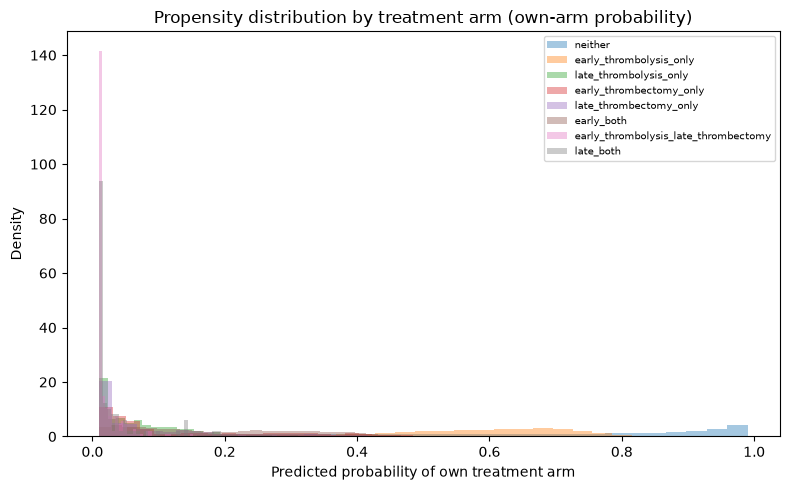

In [14]:
arm_names = {
    0: "neither", 1: "early_thrombolysis_only", 2: "late_thrombolysis_only",
    3: "early_thrombectomy_only", 4: "late_thrombectomy_only", 5: "early_both",
    6: "early_thrombolysis_late_thrombectomy", 7: "late_both",
}
baseline_code = 0
other_arm_codes = {k: v for k, v in arm_names.items() if k != baseline_code}

# 1. Own-arm propensity distribution
own_arm_prop = oof_propensity_clipped[np.arange(len(arm_int)), arm_int]

fig, ax = plt.subplots(figsize=(8, 5))
for code, name in arm_names.items():
    mask = arm_int == code
    if mask.any():
        ax.hist(own_arm_prop[mask], bins=30, alpha=0.4, density=True, label=name)
ax.set_xlabel("Predicted probability of own treatment arm")
ax.set_ylabel("Density")
ax.set_title("Propensity distribution by treatment arm (own-arm probability)")
ax.legend(fontsize=7, loc="upper right")
plt.tight_layout()
#plt.savefig("./output/propensity_overlap_own_arm.png", dpi=300)
plt.show()


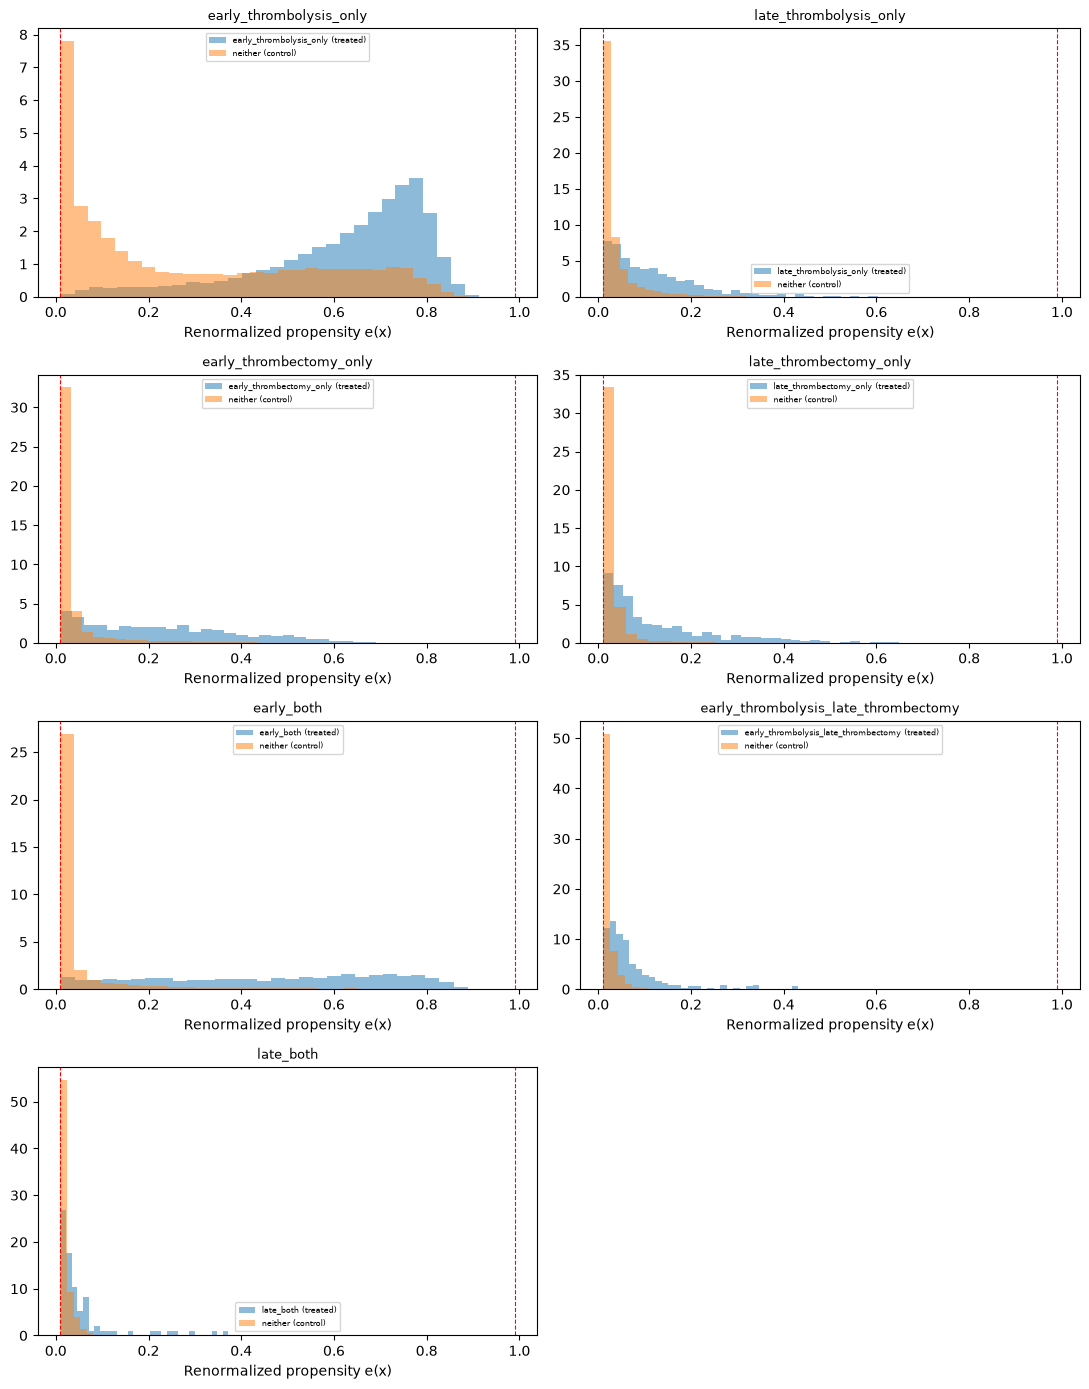

In [19]:
# 2. Pairwise overlap: baseline ("neither") vs each treated arm
fig, axes = plt.subplots(4, 2, figsize=(11, 14))
axes = axes.ravel()

for i, (code, name) in enumerate(other_arm_codes.items()):
    mask = np.isin(arm_int, [baseline_code, code])
    t_m = (arm_int[mask] == code).astype(int)
    e_m = oof_propensity_clipped[mask][:, code] / (
        oof_propensity_clipped[mask][:, code] + oof_propensity_clipped[mask][:, baseline_code]
    )
    e_m = np.clip(e_m, CLIP_LOW, CLIP_HIGH)

    ax = axes[i]
    ax.hist(e_m[t_m == 1], bins=30, alpha=0.5, density=True, label=f"{name} (treated)")
    ax.hist(e_m[t_m == 0], bins=30, alpha=0.5, density=True, label="neither (control)")
    ax.axvline(CLIP_LOW, color="red", linestyle="--", linewidth=0.8)
    ax.axvline(CLIP_HIGH, color="red", linestyle="--", linewidth=0.8)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Renormalized propensity e(x)")
    ax.legend(fontsize=6)

# Hide any unused axes
for j in range(len(other_arm_codes), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
# plt.savefig("./output/propensity_overlap_pairwise.png", dpi=300)
plt.show()


In [16]:
# 3. Extreme weight / effective sample size diagnostics
weight_diagnostics = []
for code, name in other_arm_codes.items():
    mask = np.isin(arm_int, [baseline_code, code])
    t_m = (arm_int[mask] == code).astype(int)
    e_m = oof_propensity_clipped[mask][:, code] / (
        oof_propensity_clipped[mask][:, code] + oof_propensity_clipped[mask][:, baseline_code]
    )
    e_m = np.clip(e_m, 0.01, 0.99)
    w_treat = t_m / e_m
    w_control = (1 - t_m) / (1 - e_m)
    all_w = np.concatenate([w_treat[t_m == 1], w_control[t_m == 0]])
    ess = (all_w.sum() ** 2) / (all_w ** 2).sum()
    weight_diagnostics.append({
        "treatment_group": name,
        "n": int(mask.sum()),
        "max_weight": float(all_w.max()),
        "pct_weight_gt_10": float((all_w > 10).mean() * 100),
        "effective_sample_size": float(ess),
        "ess_pct_of_n": float(ess / mask.sum() * 100),
    })

weight_diag_df = pd.DataFrame(weight_diagnostics).set_index("treatment_group").round(2)
weight_diag_df.to_csv("./output/ipw_weight_diagnostics.csv")
weight_diag_df


,n,max_weight,pct_weight_gt_10,effective_sample_size,ess_pct_of_n
treatment_group,,,,,
early_thrombolysis_only,53935,92.08,0.72,26991.07,50.04
late_thrombolysis_only,31850,100.00,1.60,3202.84,10.06
early_thrombectomy_only,32083,98.32,1.06,4316.24,13.45
late_thrombectomy_only,31403,100.00,0.96,3313.69,10.55
early_both,33447,91.73,0.75,5970.38,17.85
early_thrombolysis_late_thrombectomy,31103,93.74,0.58,5696.88,18.32
late_both,30957,97.72,0.22,5592.50,18.07


### IPW average treatment effect estimates (Hajek estimator)

In [17]:
def ipw_ate(y, arm_int, prop, baseline_code, arm_code, n_boot=500, seed=42):
    mask = np.isin(arm_int, [baseline_code, arm_code])
    y_m = y[mask]
    t_m = (arm_int[mask] == arm_code).astype(int)
    e_m = prop[mask][:, arm_code] / (
        prop[mask][:, arm_code] + prop[mask][:, baseline_code]
    )
    e_m = np.clip(e_m, 0.01, 0.99)

    w_treat = t_m / e_m
    w_control = (1 - t_m) / (1 - e_m)

    mu1 = np.sum(w_treat * y_m) / np.sum(w_treat)
    mu0 = np.sum(w_control * y_m) / np.sum(w_control)
    ate = mu1 - mu0

    rng = np.random.default_rng(seed)
    boot_ates = []
    idx = np.arange(len(y_m))
    for _ in range(n_boot):
        b_idx = rng.choice(idx, size=len(idx), replace=True)
        yb, tb, eb = y_m[b_idx], t_m[b_idx], e_m[b_idx]
        wt, wc = tb / eb, (1 - tb) / (1 - eb)
        if wt.sum() == 0 or wc.sum() == 0:
            continue
        boot_ates.append(np.sum(wt * yb) / np.sum(wt) - np.sum(wc * yb) / np.sum(wc))

    boot_ates = np.array(boot_ates)
    ci_lower, ci_upper = np.percentile(boot_ates, [2.5, 97.5])
    return ate, boot_ates.std(), ci_lower, ci_upper, int(mask.sum())


ipw_results = []
for code, name in other_arm_codes.items():
    ate, se, lo, hi, n = ipw_ate(y, arm_int, oof_propensity_clipped, baseline_code, code)
    ipw_results.append({
        "treatment_group": name, "mean": ate, "std": se,
        "count": n, "95% CI lower": lo, "95% CI upper": hi,
    })

ipw_summary = pd.DataFrame(ipw_results).set_index("treatment_group")

ordered_arms = [
    "early_thrombolysis_only", "late_thrombolysis_only", "early_thrombectomy_only",
    "late_thrombectomy_only", "early_both", "early_thrombolysis_late_thrombectomy", "late_both",
]
ipw_summary = ipw_summary.reindex(ordered_arms).round(4)
#ipw_summary.to_csv(f"./output/ipw_ate_estimates_{MRS_TARGET}.csv")
ipw_summary


,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
early_thrombolysis_only,0.0953,0.0056,53935,0.0840,0.1064
late_thrombolysis_only,0.1229,0.0233,31850,0.0783,0.1721
early_thrombectomy_only,0.1490,0.0242,32083,0.0994,0.1920
late_thrombectomy_only,0.0613,0.0286,31403,0.0089,0.1233
early_both,0.1909,0.0220,33447,0.1520,0.2333
early_thrombolysis_late_thrombectomy,0.1661,0.0402,31103,0.0959,0.2474
late_both,0.1170,0.0674,30957,-0.0093,0.2550


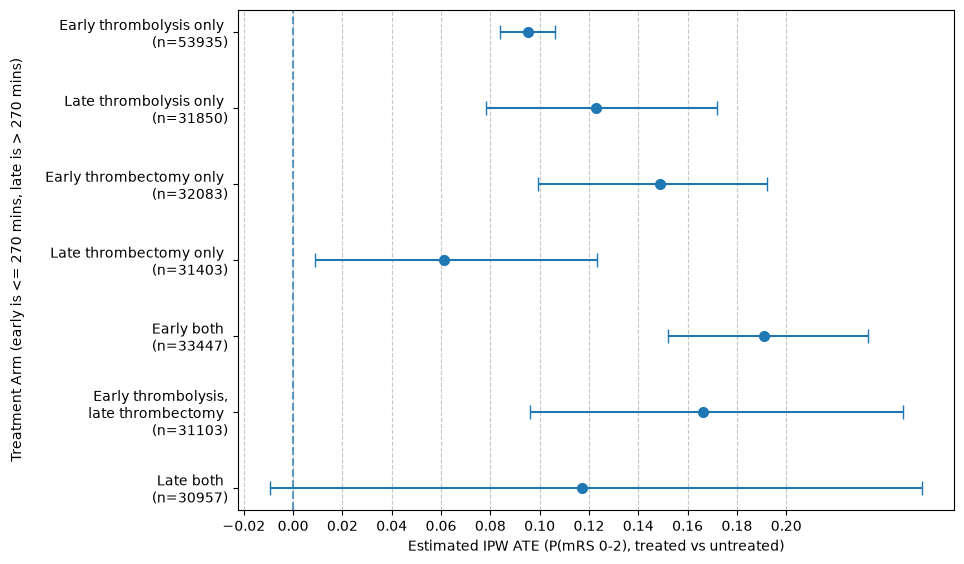

In [18]:
rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both"
}
n_values = ipw_summary["count"].astype(int).to_dict()
rename_dict = {k: f"{v} \n(n={n_values.get(k, 0)})" for k, v in rename_dict.items()}

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    y=range(len(ipw_summary.index) - 1, -1, -1),
    x=ipw_summary["mean"],
    xerr=[
        ipw_summary["mean"] - ipw_summary["95% CI lower"],
        ipw_summary["95% CI upper"] - ipw_summary["mean"],
    ],
    fmt="o",
    markersize=7,
    capsize=5,
    label="Estimated IPW ATE with 95% CI",
)
ax.set_xticks(np.arange(-0.02, 0.201, 0.02))
ax.set_yticks(range(len(ipw_summary.index) - 1, -1, -1))
ax.set_yticklabels([rename_dict.get(label, label.replace('_', ' ')) for label in ipw_summary.index])
ax.set_xlabel(f"Estimated IPW ATE (P(mRS 0-{MRS_TARGET}), treated vs untreated)")
ax.set_ylabel(f"Treatment Arm (early is <= {CUTOFF} mins, late is > {CUTOFF} mins)", labelpad=15)
ax.grid(axis="x", linestyle="--", alpha=0.7)
ax.axvline(x=0, linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
#plt.savefig(f"./output/ipw_counterfactual_ate_estimates_{MRS_TARGET}.png", dpi=300)
plt.show()
